In [34]:
df.head()

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,Month
0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,1275.0,-1148.0,7,Furniture,Bookcases,April
1,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,66.0,-12.0,5,Clothing,Stole,April
2,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,8.0,-2.0,3,Clothing,Hankerchief,April
3,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,80.0,-56.0,4,Electronics,Electronic Games,April
4,B-25602,2018-04-01,Pearl,Maharashtra,Pune,168.0,-111.0,2,Electronics,Phones,April


# E-Commerce Sales Exploratory Data Analysis (EDA)

Author: Samruddhi Gawade

Internship Task: Exploratory Data Analysis (EDA) Project

Tools Used: Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

# E-Commerce Sales Exploratory Data Analysis (EDA)

## Objective
The objective of this project is to analyze e-commerce sales data to identify trends, customer behavior, profitability patterns, and key business insights using data visualization and statistical analysis.

## Dataset Information
- Total Records: 1500
- Total Features: 11
- Missing Values: 0
- Dataset Type: E-Commerce Sales Data

In [35]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1500, 11)


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

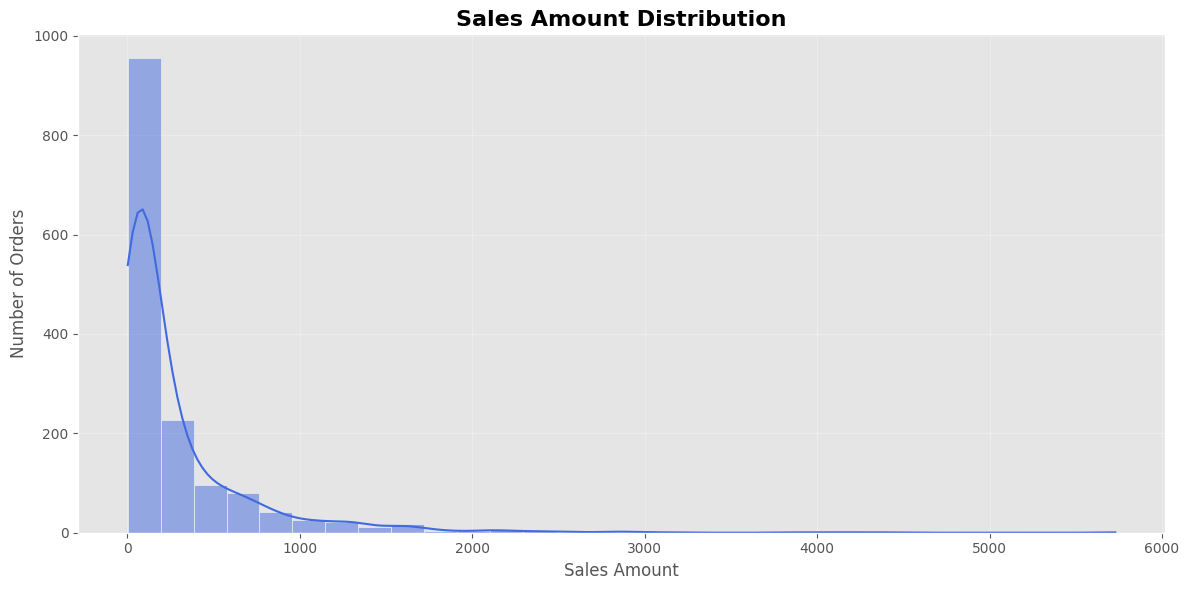

In [37]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Amount",
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Sales Amount Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Sales Amount", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../images/sales_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24992\2679790386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


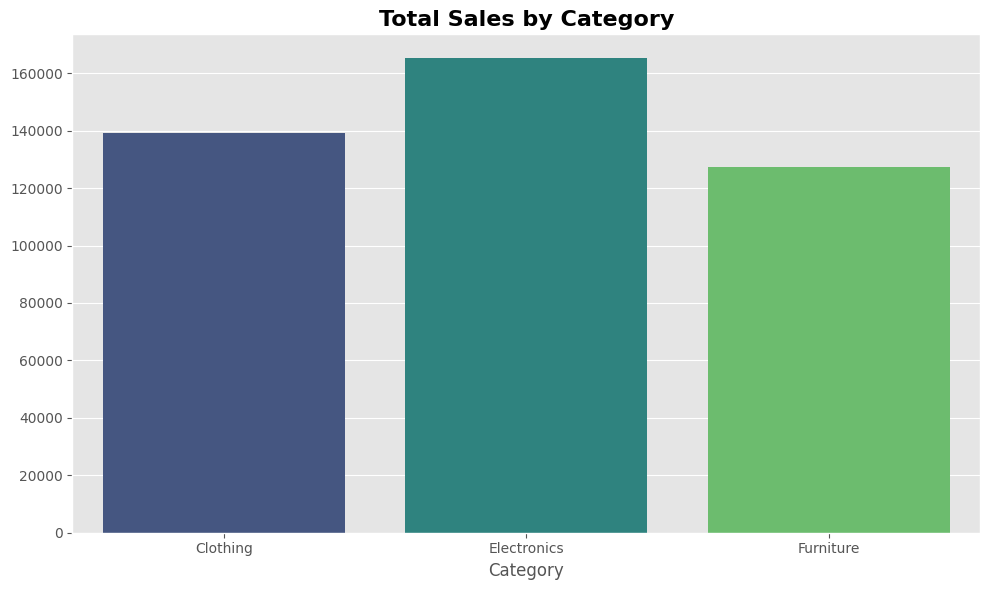

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

plt.title("Total Sales by Category", fontsize=16, fontweight="bold")

plt.tight_layout()


plt.savefig("../images/category_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Business Insight:

Electronics is the highest revenue-generating category among all product categories. This indicates strong customer demand and suggests that the company should prioritize inventory, marketing, and promotions for Electronics products to maximize revenue.

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24992\3178367472.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


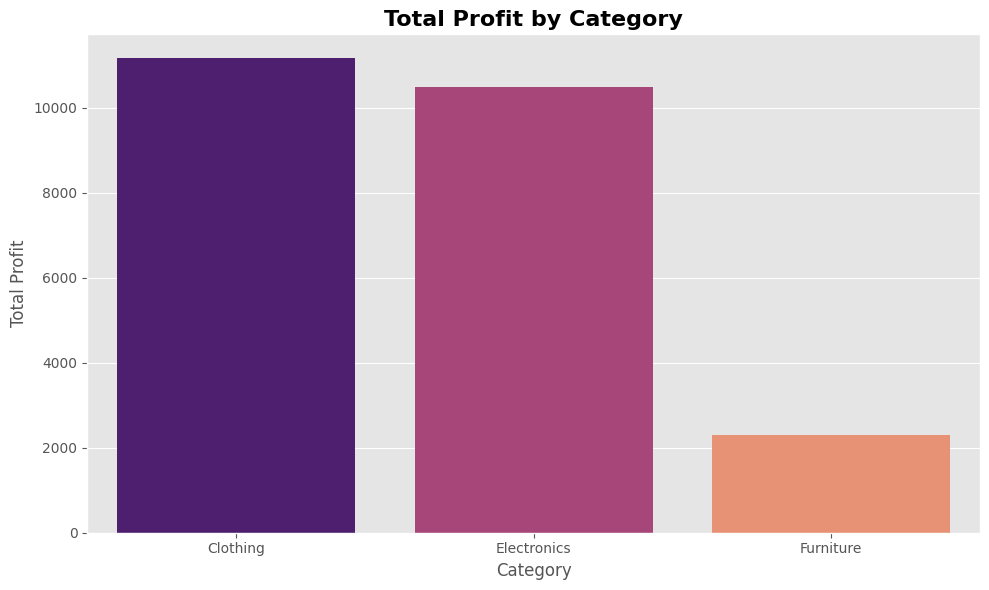

In [39]:
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=profit_by_category.index,
    y=profit_by_category.values,
    palette="magma"
)

plt.title("Total Profit by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.savefig("../images/profit_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

Business Insight:

Although Electronics generates the highest sales revenue, Clothing generates the highest profit. This suggests that Clothing products have better profit margins and contribute more effectively to the company's overall profitability.

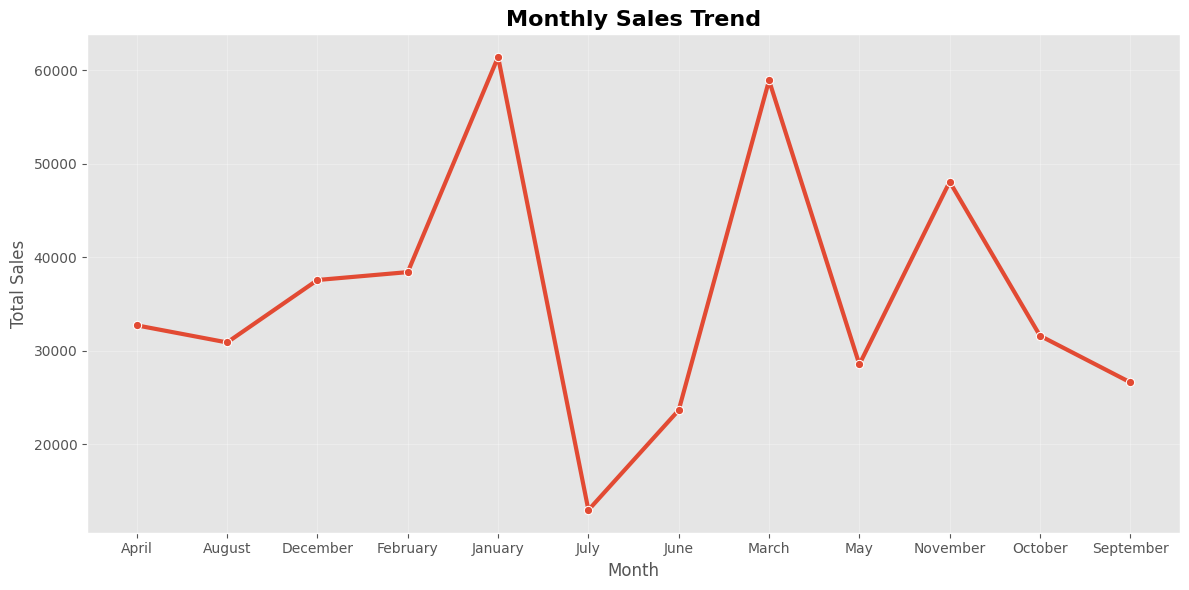

In [40]:
monthly_sales = df.groupby("Month")["Amount"].sum()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o",
    linewidth=3
)

plt.title("Monthly Sales Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Business Insight:

January recorded the highest sales among all months, indicating a strong start to the year. The company can analyze the factors behind January's performance and replicate successful strategies in other months.

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24992\3468229382.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


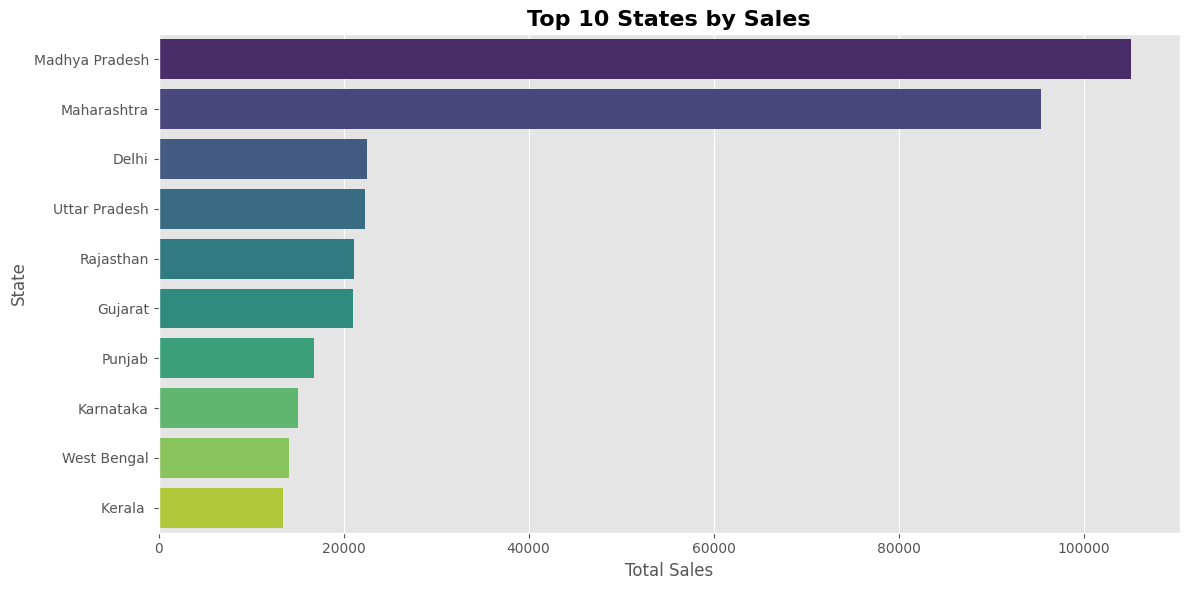

In [41]:
top_states = (
    df.groupby("State")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    palette="viridis"
)

plt.title("Top 10 States by Sales", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("State")

plt.tight_layout()
plt.savefig("../images/top_states_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Business Insight:

Madhya Pradesh generated the highest sales among all states. This indicates a strong customer base and market demand in the region. The company should focus on customer retention and targeted marketing campaigns in Madhya Pradesh to sustain growth.

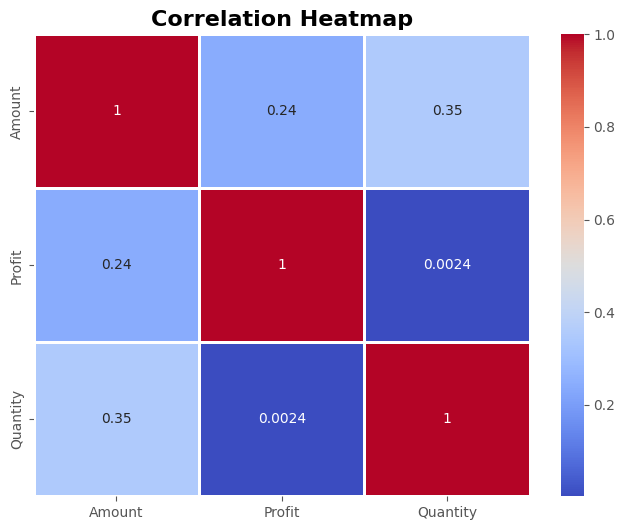

In [42]:
plt.figure(figsize=(8,6))

numeric_df = df[["Amount", "Profit", "Quantity"]]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=1
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Business Insight:

The correlation between Amount and Profit is 0.24, indicating a weak positive relationship. This suggests that higher sales do not always lead to proportionally higher profits, highlighting the importance of profit margin management.

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24992\2902410327.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


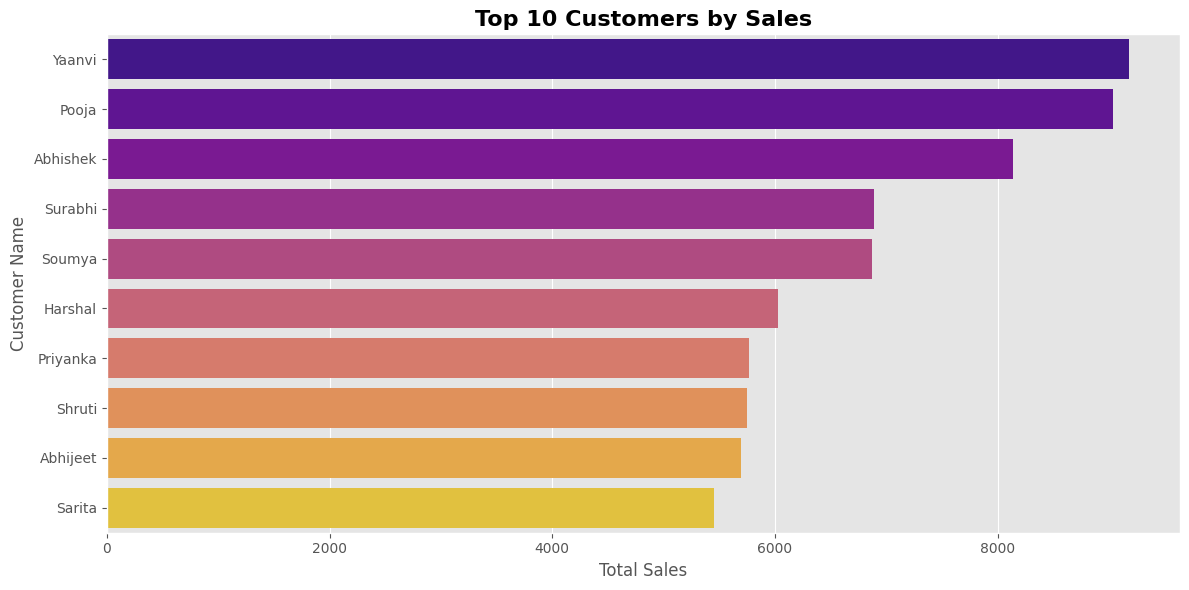

In [43]:
top_customers = (
    df.groupby("CustomerName")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    palette="plasma"
)

plt.title("Top 10 Customers by Sales", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")

plt.tight_layout()
plt.savefig("../images/top_customers_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Business Insight:

Yanavi is the highest-value customer in terms of total sales contribution. Maintaining strong customer relationships and providing personalized offers can help improve customer retention and increase long-term revenue.

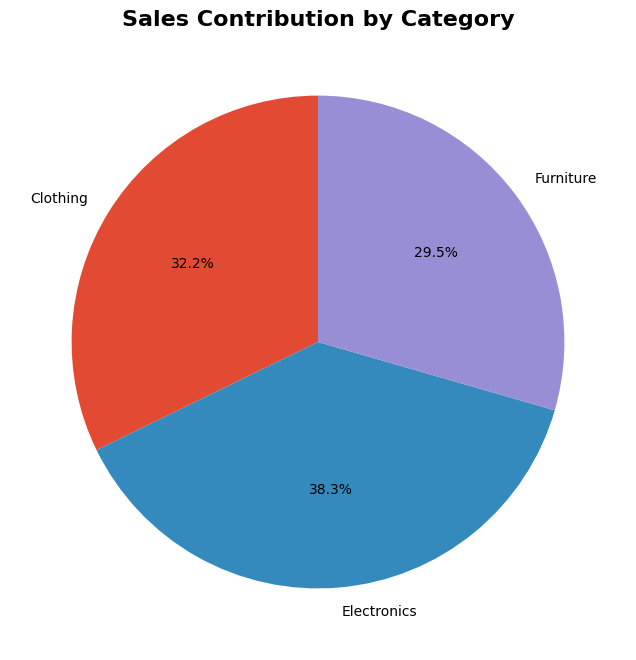

In [44]:
category_sales = df.groupby("Category")["Amount"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Sales Contribution by Category",
    fontsize=16,
    fontweight="bold"
)

plt.savefig("../images/category_contribution_pie.png", dpi=300, bbox_inches="tight")
plt.show()

Business Insight:

Electronics contributes 38.3% of total sales, making it the largest revenue-generating category. This highlights the importance of Electronics products in driving overall business performance.

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      1500 non-null   str    
 1   Order Date    1500 non-null   str    
 2   CustomerName  1500 non-null   str    
 3   State         1500 non-null   str    
 4   City          1500 non-null   str    
 5   Amount        1500 non-null   float64
 6   Profit        1500 non-null   float64
 7   Quantity      1500 non-null   int64  
 8   Category      1500 non-null   str    
 9   Sub-Category  1500 non-null   str    
 10  Month         1500 non-null   str    
dtypes: float64(2), int64(1), str(8)
memory usage: 221.5 KB


In [46]:
df.isnull().sum()

Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
Month           0
dtype: int64

In [47]:
import pandas as pd

df = pd.read_csv("../data/Cleaned_Ecommerce_Data.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [48]:
os.listdir()

['EDA_Analysis.ipynb']

In [49]:
import os

print(os.getcwd())

c:\Users\VICTUS\OneDrive\Desktop\EDA_Ecommerce_Analysis\notebook


In [50]:
import pandas as pd

In [51]:

print("EDA Project Started")

EDA Project Started


# Conclusion

This Exploratory Data Analysis (EDA) project analyzed 1,500 e-commerce sales records to identify trends, customer behavior, and business performance. The dataset was clean and contained no missing values.

Key findings revealed that Electronics generated the highest sales revenue, while Clothing generated the highest profit. January recorded the highest sales among all months, and Madhya Pradesh emerged as the top-performing state. Correlation analysis showed a weak positive relationship between sales amount and profit, indicating that increasing sales alone does not always guarantee higher profitability.

The analysis also identified Yanavi as the highest-value customer and highlighted the significant contribution of Electronics products, which accounted for 38.3% of total sales.

Overall, the project successfully uncovered valuable business insights that can support data-driven decision-making and strategic planning.


# Business Recommendations

1. Increase inventory and promotional efforts for Electronics products due to their strong sales performance.

2. Focus on expanding the Clothing category, as it generates the highest profit margins.

3. Analyze the factors behind January's strong sales performance and apply successful strategies throughout the year.

4. Strengthen marketing campaigns and customer engagement in Madhya Pradesh to maintain market leadership.

5. Improve profit margins by optimizing pricing and operational costs, as higher sales do not always translate into higher profits.

6. Implement customer retention programs for high-value customers such as Yanavi to maximize long-term revenue.
